In [4]:
!pip install mne python-picard -q

In [29]:
from google.colab import drive
drive.mount('/content/drive')

# Ruta a la carpeta donde están los archivos .txt
import os
os.chdir('/content/drive/MyDrive/Ingeniería Biomédica PUCP_UPCH/7mo Semestre/Intro a Señales/EEG_archivos')  # <-- Cambiar si es necesario

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks
from scipy.stats import kurtosis
import glob, unicodedata, warnings

mne.set_log_level("WARNING")
mne.viz.set_browser_backend("matplotlib")
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 4)

In [43]:
FS      = 1000
VCC     = 3.3
ADC_RES = 1024
GAIN    = 40_000

CH_NAMES = ["Fp1", "Fp2"]

ARCHIVOS = {
    "1_Primer_Ritmo_Basal":               "Basal 1",
    "2_Mirada-Fija-En-Un-Punto":          "Mirada Fija",
    "3_Segundo-Ritmo-Basal":              "Basal 2",
    "4_Parpadeo_Y_Masticacion_Constante": "Parpadeo + Masticación",
    "5_Tercer-Ritmo-Basal":               "Basal 3",
    "6-1_Musica-Relajante":               "Música Relajante",
    "6-2_Musica-Estresante":              "Música Estresante",
}

In [44]:
def _normalizar(s):
    s = unicodedata.normalize('NFKD', s)
    return ''.join(c for c in s if not unicodedata.combining(c)).lower()

def buscar_archivo(patron):
    patron_norm = _normalizar(patron)
    for f in glob.glob("*.txt"):
        if patron_norm in _normalizar(f):
            return f
    raise FileNotFoundError(f"No se encontró ningún .txt que contenga '{patron}'.")

def leer_canal(path, col_nombre):
    nombres_col = ["nSeq", "I1", "I2", "O1", "O2", "A1", "A2", "extra"]
    df = pd.read_csv(path, sep="\t", comment="#", header=None,
                      names=nombres_col, usecols=["A1", "A2"])
    adc = df[col_nombre].values.astype(float)
    adc = adc[np.isfinite(adc)]
    eeg_volts = (((adc / ADC_RES) - 0.5) * VCC) / GAIN
    eeg_volts -= np.median(eeg_volts)
    return eeg_volts

In [45]:
datos = {}
montage = mne.channels.make_standard_montage("standard_1020")

for nombre, etiqueta in ARCHIVOS.items():
    archivo = buscar_archivo(nombre)
    fp1 = leer_canal(archivo, "A1")
    fp2 = leer_canal(archivo, "A2")
    n = min(len(fp1), len(fp2))

    info = mne.create_info(ch_names=CH_NAMES, sfreq=FS, ch_types=["eeg", "eeg"])
    raw_crudo = mne.io.RawArray(np.array([fp1[:n], fp2[:n]]), info)
    raw_crudo.set_montage(montage, on_missing="warn")

    datos[nombre] = {"label": etiqueta, "raw_crudo": raw_crudo}
    print(f"{etiqueta:25s} cargado ({n/FS:.1f} s)")

Basal 1                   cargado (62.2 s)
Mirada Fija               cargado (62.5 s)
Basal 2                   cargado (33.3 s)
Parpadeo + Masticación    cargado (62.4 s)
Basal 3                   cargado (51.5 s)
Música Relajante          cargado (60.8 s)
Música Estresante         cargado (64.5 s)


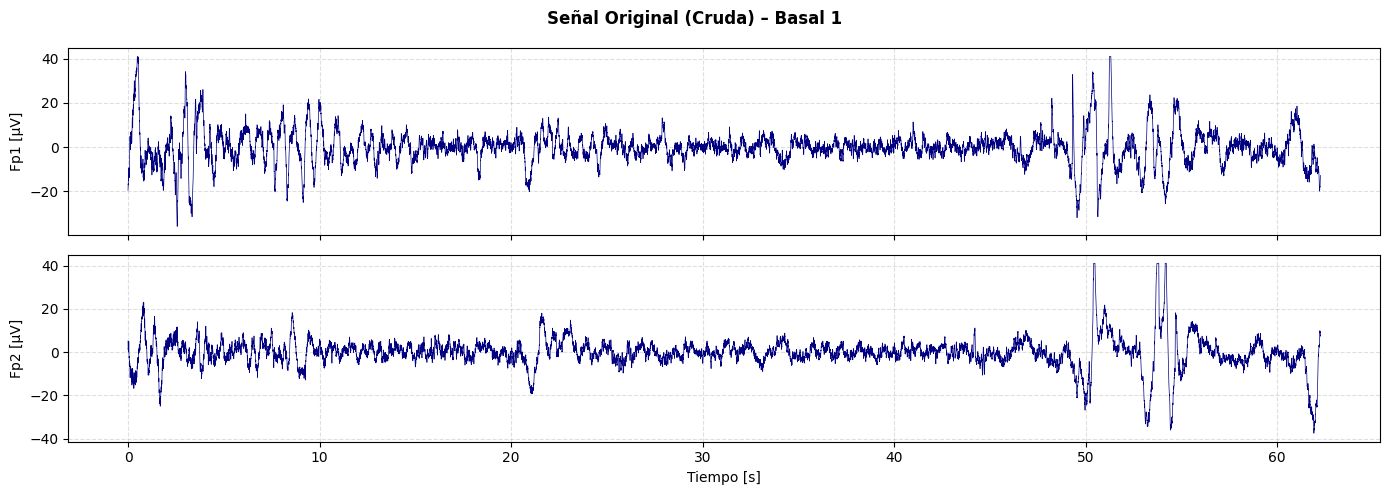

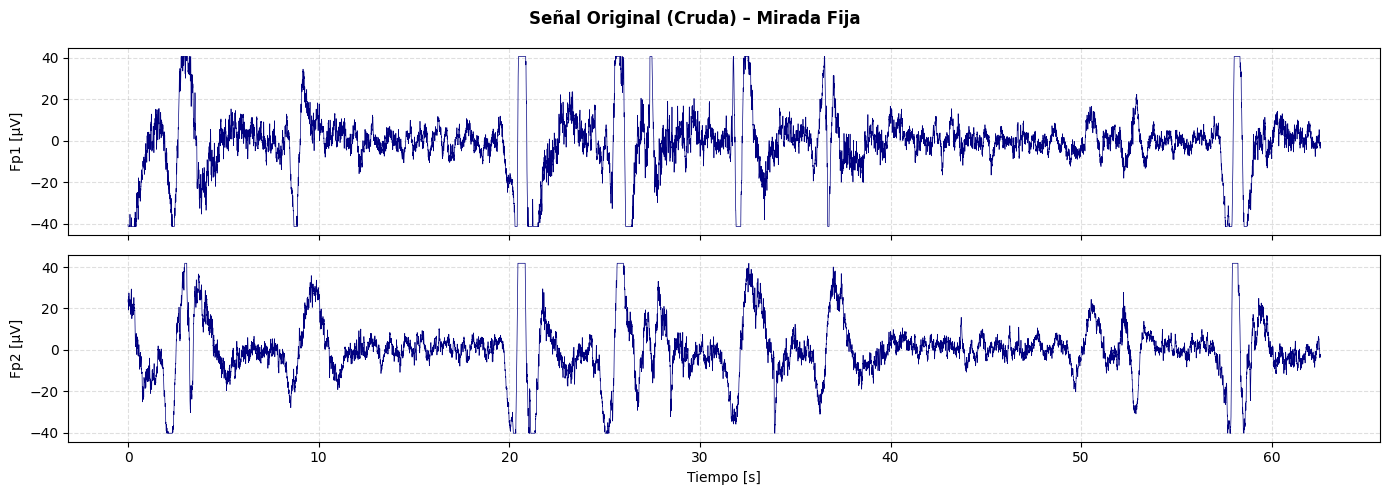

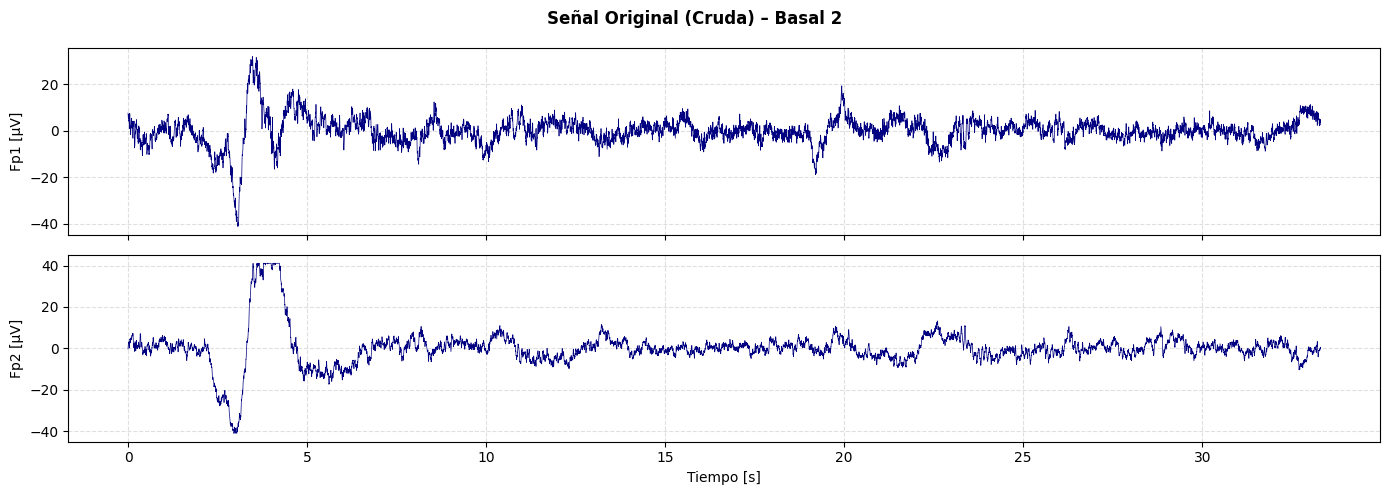

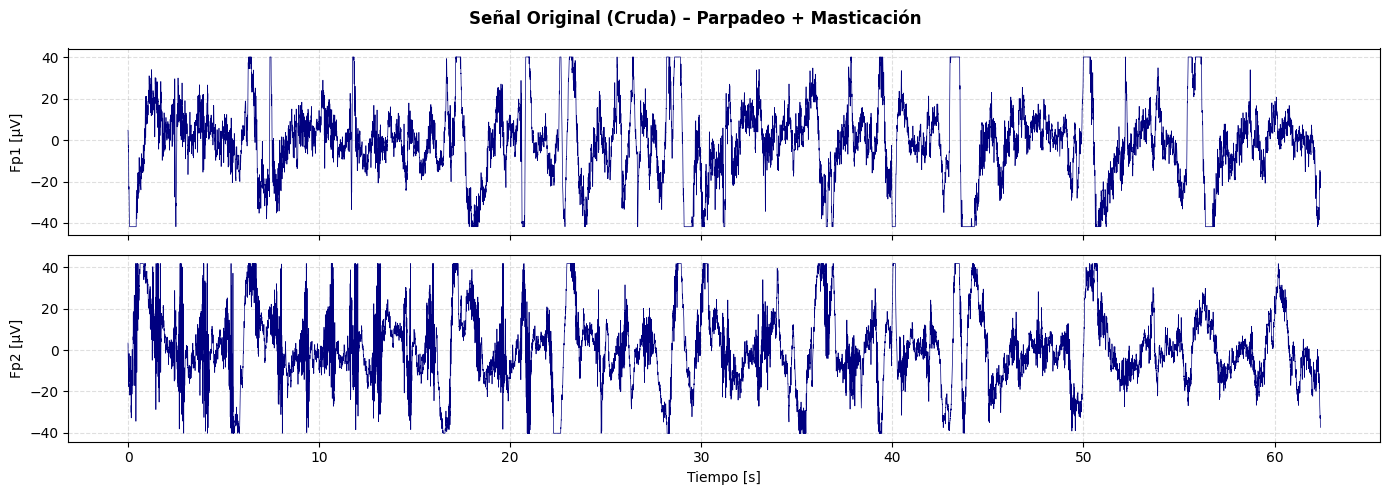

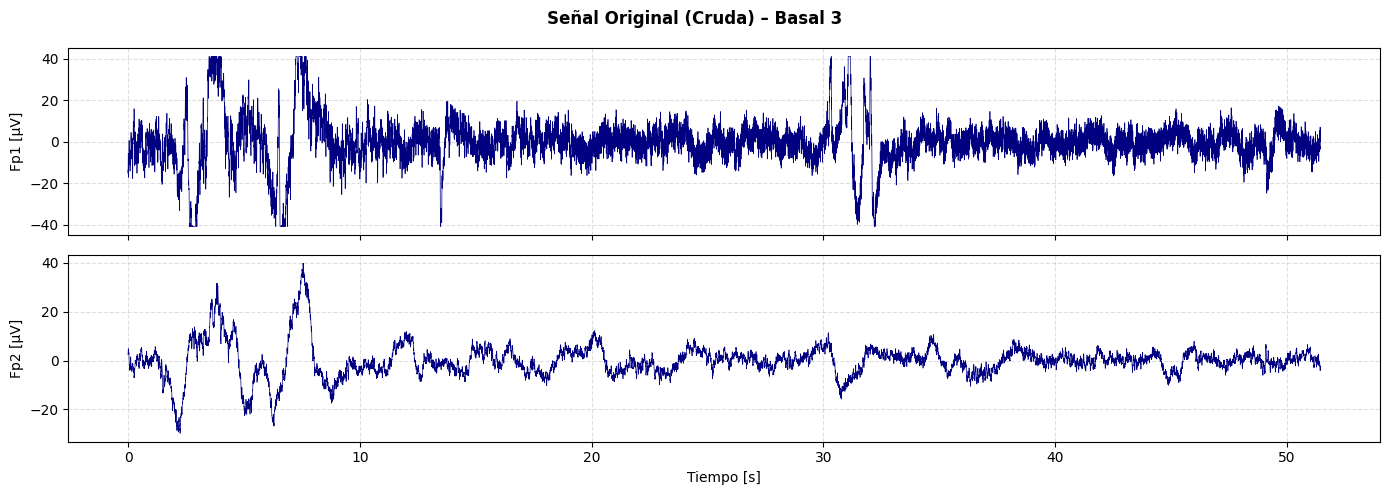

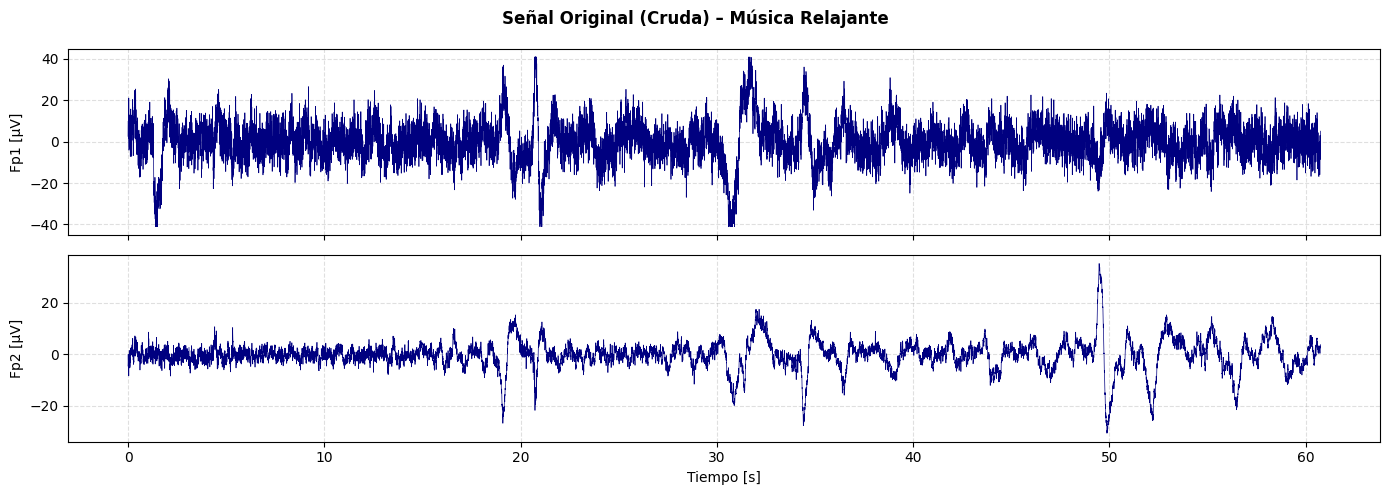

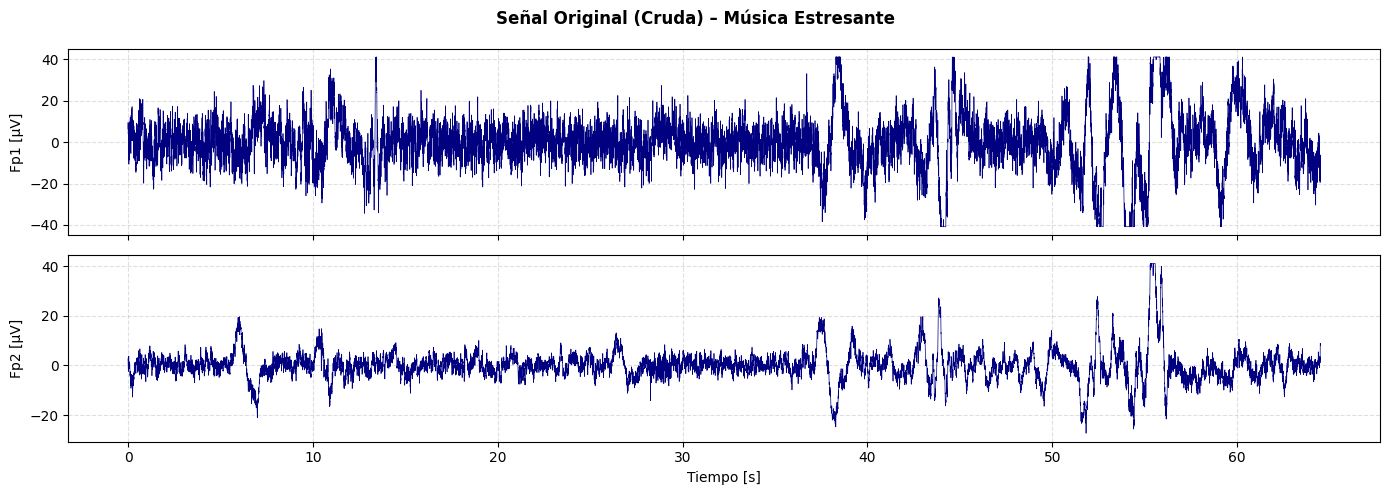

In [46]:
for nombre, d in datos.items():
    señal_uv = d["raw_crudo"].get_data() * 1e6
    t = np.arange(señal_uv.shape[1]) / FS

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    for i, ch in enumerate(CH_NAMES):
        axes[i].plot(t, señal_uv[i], lw=0.5, color="navy")
        axes[i].set_ylabel(f"{ch} [µV]")
        axes[i].grid(True, ls="--", alpha=0.4)
    axes[-1].set_xlabel("Tiempo [s]")
    fig.suptitle(f"Señal Original (Cruda) – {d['label']}", fontweight="bold")
    plt.tight_layout(); plt.show()

In [55]:
for nombre, d in datos.items():
    raw_filt = d["raw_crudo"].copy()
    raw_filt.notch_filter(freqs=[60.0], verbose=False)
    raw_filt.filter(l_freq=0.5, h_freq=40.0, verbose=False)
    d["raw_filt"] = raw_filt

print("Preprocesamiento aplicado a todas las grabaciones.")

Preprocesamiento aplicado a todas las grabaciones.


In [56]:
for nombre, d in datos.items():
    ica = mne.preprocessing.ICA(n_components=2, method="picard", random_state=97, max_iter="auto")
    ica.fit(d["raw_filt"], verbose=False)
    d["ica"] = ica

print("ICA (Picard, n_components=2) ajustado en todas las grabaciones.")

ICA (Picard, n_components=2) ajustado en todas las grabaciones.


In [57]:
def sugerir_componente(ica, raw):
    fuentes = ica.get_sources(raw).get_data()
    filas = []
    for i, src in enumerate(fuentes):
        k = kurtosis(src)
        peaks, _ = find_peaks(np.abs(src), height=3*src.std(), distance=int(0.3*FS))
        filas.append({"componente": i, "kurtosis": round(k, 2), "n_picos_grandes": len(peaks)})
    df = pd.DataFrame(filas)
    sugerida = int(df.sort_values("kurtosis", ascending=False).iloc[0]["componente"])
    return sugerida, df

Basal 1  (1_Primer_Ritmo_Basal)


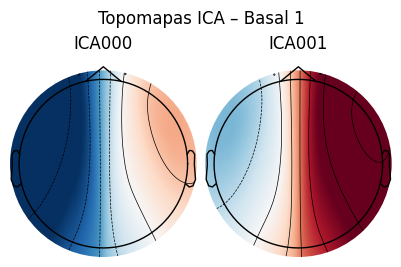

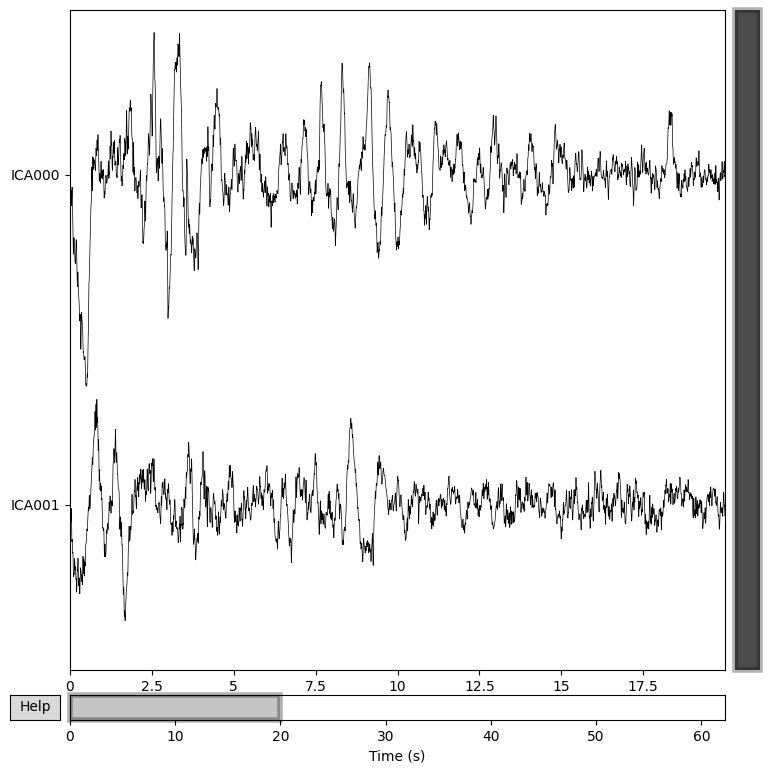

 componente  kurtosis  n_picos_grandes
          0      6.78               11
          1     10.80                9
>> Componente sugerida como artefacto: IC1

Mirada Fija  (2_Mirada-Fija-En-Un-Punto)


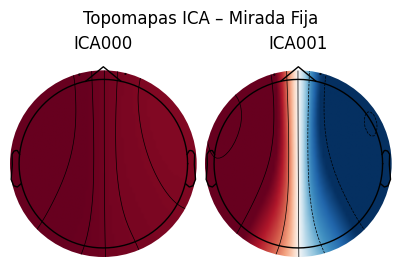

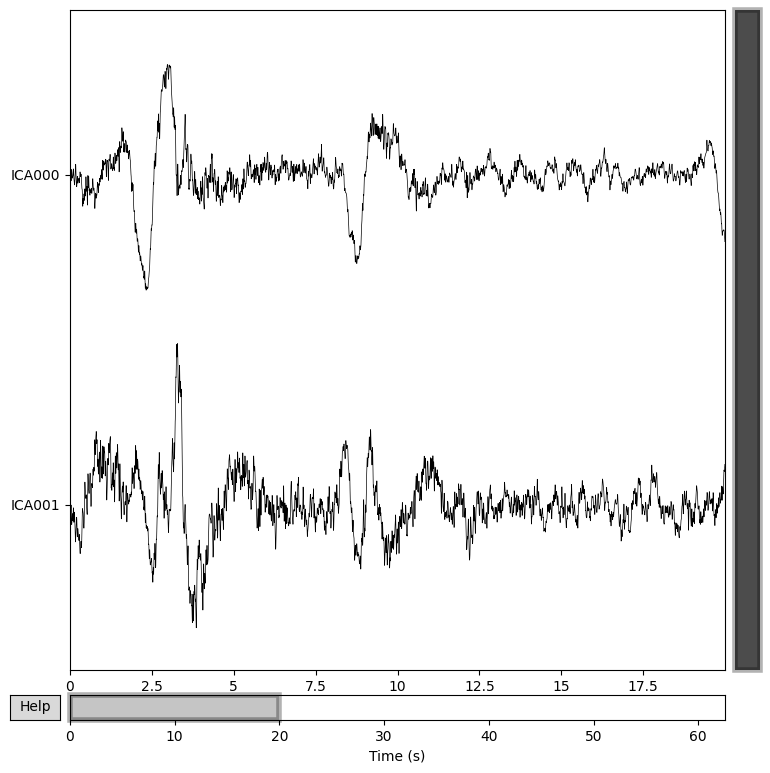

 componente  kurtosis  n_picos_grandes
          0      5.40               11
          1      3.62               17
>> Componente sugerida como artefacto: IC0

Basal 2  (3_Segundo-Ritmo-Basal)


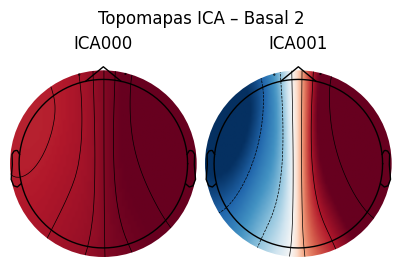

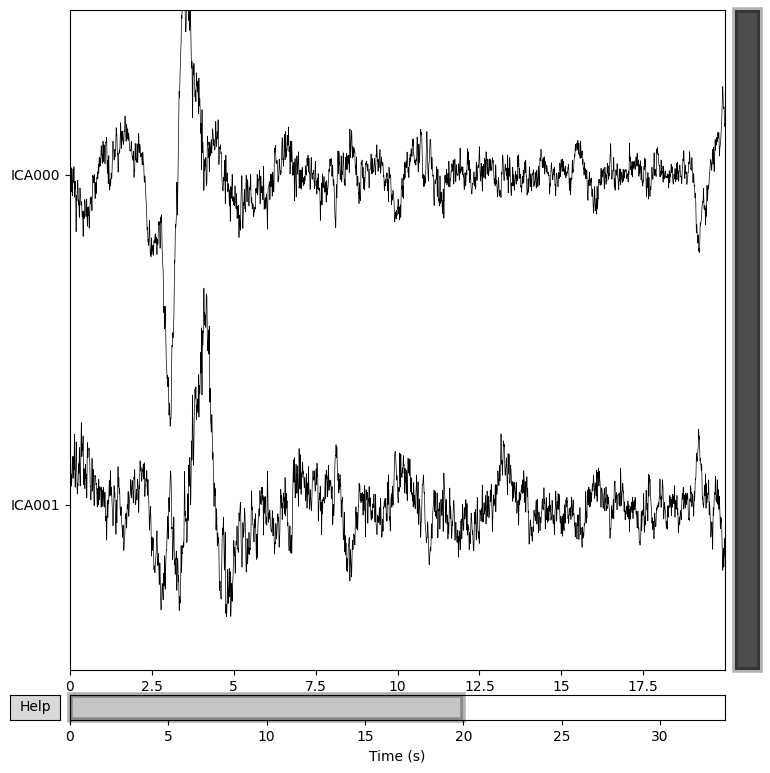

 componente  kurtosis  n_picos_grandes
          0     17.86                3
          1      6.93                5
>> Componente sugerida como artefacto: IC0

Parpadeo + Masticación  (4_Parpadeo_Y_Masticacion_Constante)


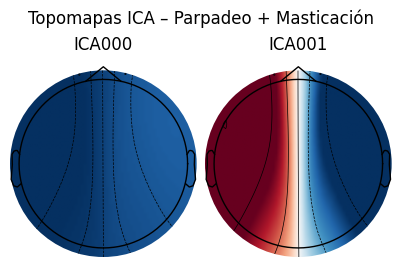

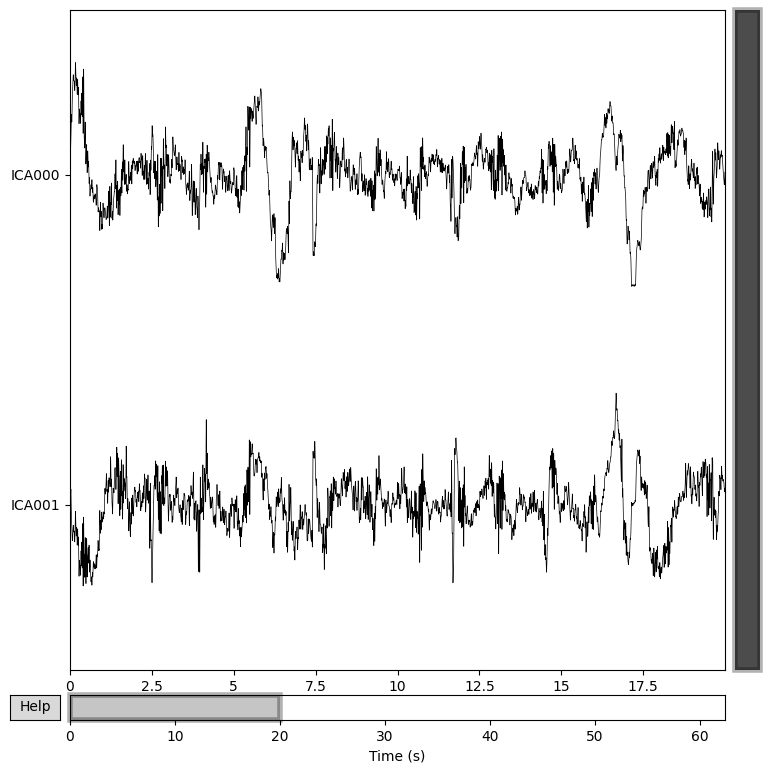

 componente  kurtosis  n_picos_grandes
          0      2.13                7
          1      1.36                9
>> Componente sugerida como artefacto: IC0

Basal 3  (5_Tercer-Ritmo-Basal)


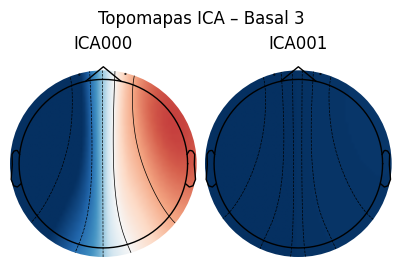

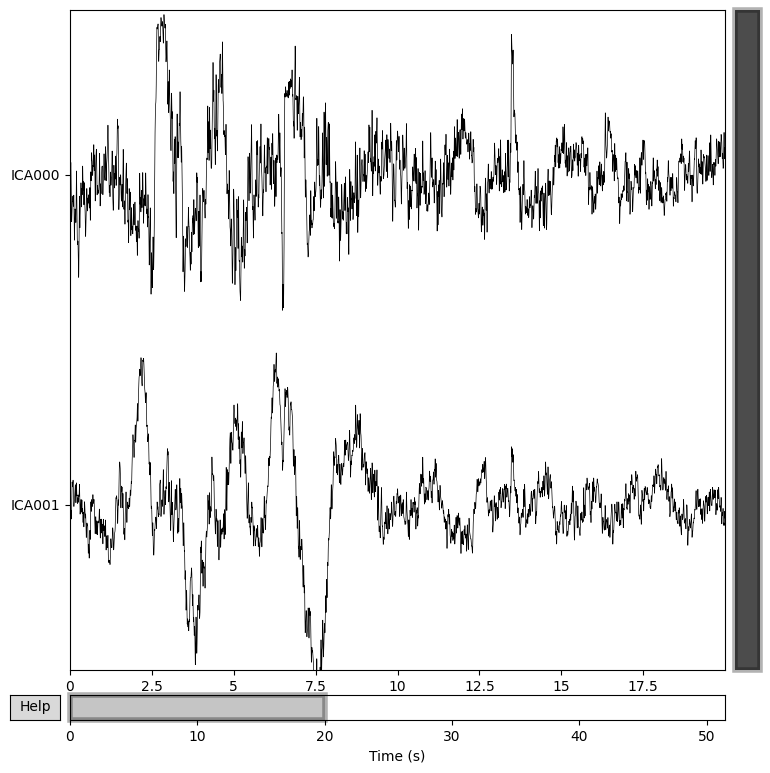

 componente  kurtosis  n_picos_grandes
          0      3.99               14
          1      7.84                8
>> Componente sugerida como artefacto: IC1

Música Relajante  (6-1_Musica-Relajante)


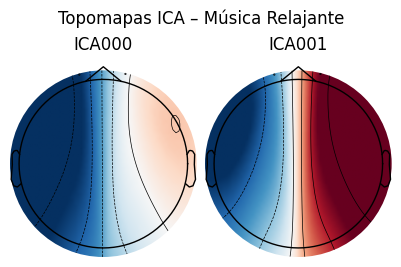

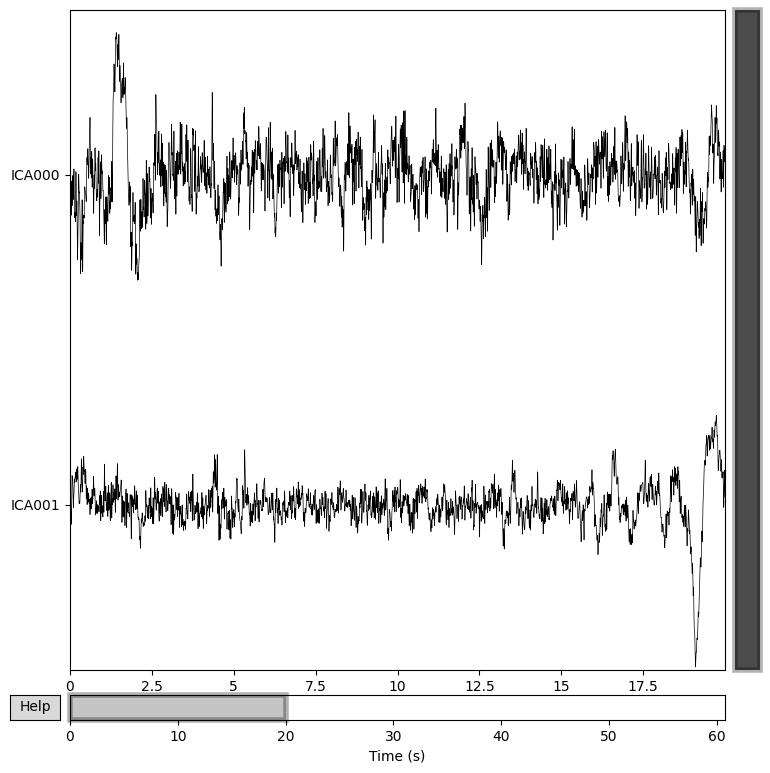

 componente  kurtosis  n_picos_grandes
          0      4.28                9
          1      6.58                7
>> Componente sugerida como artefacto: IC1

Música Estresante  (6-2_Musica-Estresante)


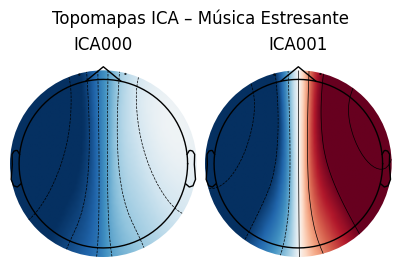

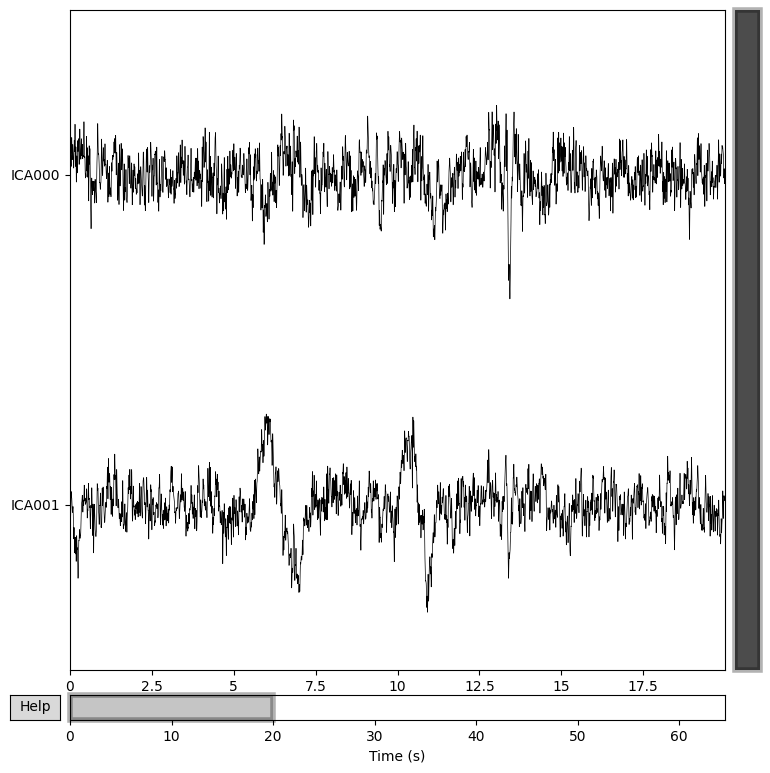

 componente  kurtosis  n_picos_grandes
          0      4.98               12
          1      4.17               10
>> Componente sugerida como artefacto: IC0



In [58]:
resultados_ica = {}

for nombre, d in datos.items():
    ica, raw = d["ica"], d["raw_filt"]

    print("="*70)
    print(f"{d['label']}  ({nombre})")
    print("="*70)

    ica.plot_components(title=f"Topomapas ICA – {d['label']}")
    ica.plot_sources(raw, title=f"Fuentes ICA – {d['label']}")

    sugerida, df_scores = sugerir_componente(ica, raw)
    print(df_scores.to_string(index=False))
    print(f">> Componente sugerida como artefacto: IC{sugerida}\n")

    resultados_ica[nombre] = {"sugerida": sugerida, "scores": df_scores}

In [60]:
EXCLUIR_MANUAL = {}   # edita aquí si quieres forzar otra componente, ej. {"4_Parpadeo_Y_Masticacion_Constante": [1]}

for nombre, d in datos.items():
    ica, raw = d["ica"], d["raw_filt"]
    excluir = EXCLUIR_MANUAL.get(nombre, [resultados_ica[nombre]["sugerida"]])

    ica.exclude = excluir
    raw_limpio = raw.copy()
    ica.apply(raw_limpio, verbose=False)

    d["raw_limpio"] = raw_limpio
    d["excluidas"] = excluir
    print(f"{d['label']:30s} -> componente(s) excluida(s): {excluir}")

Basal 1                        -> componente(s) excluida(s): [1]
Mirada Fija                    -> componente(s) excluida(s): [0]
Basal 2                        -> componente(s) excluida(s): [0]
Parpadeo + Masticación         -> componente(s) excluida(s): [0]
Basal 3                        -> componente(s) excluida(s): [1]
Música Relajante               -> componente(s) excluida(s): [1]
Música Estresante              -> componente(s) excluida(s): [0]


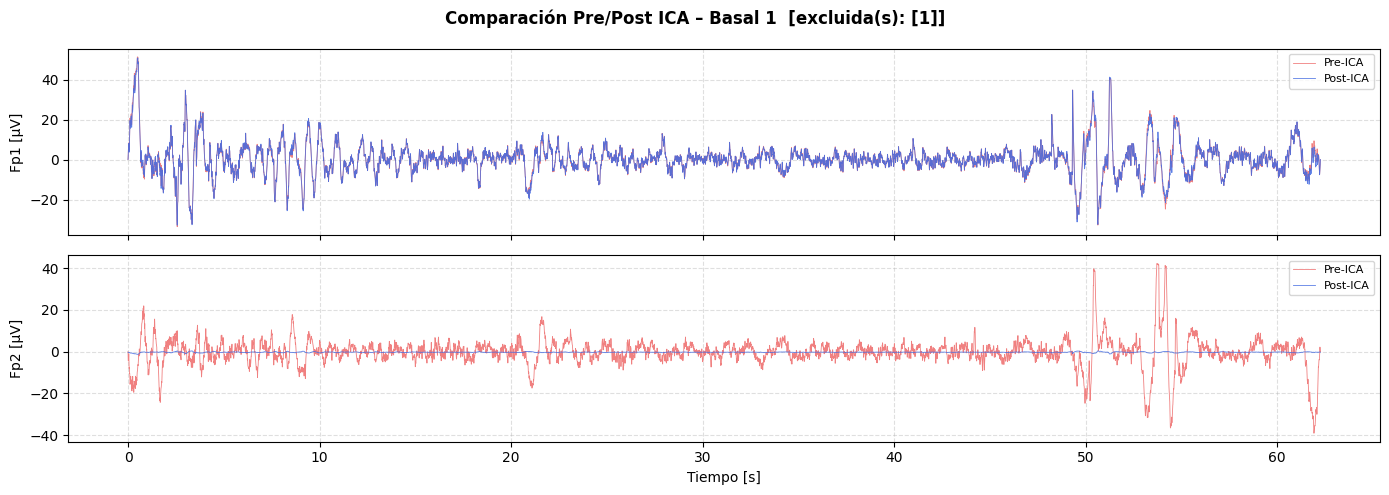

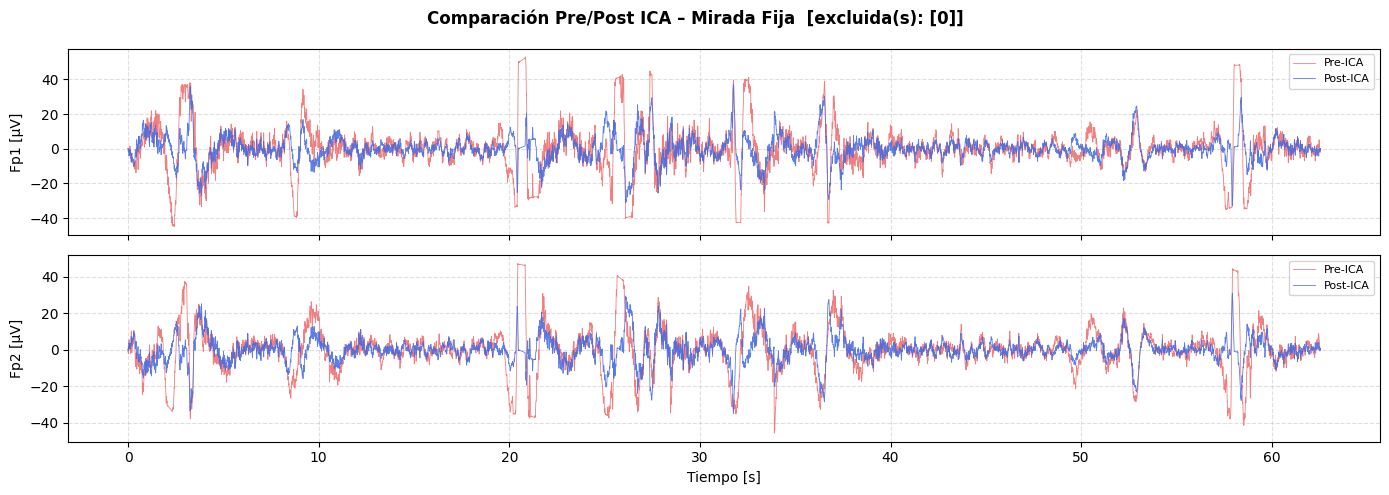

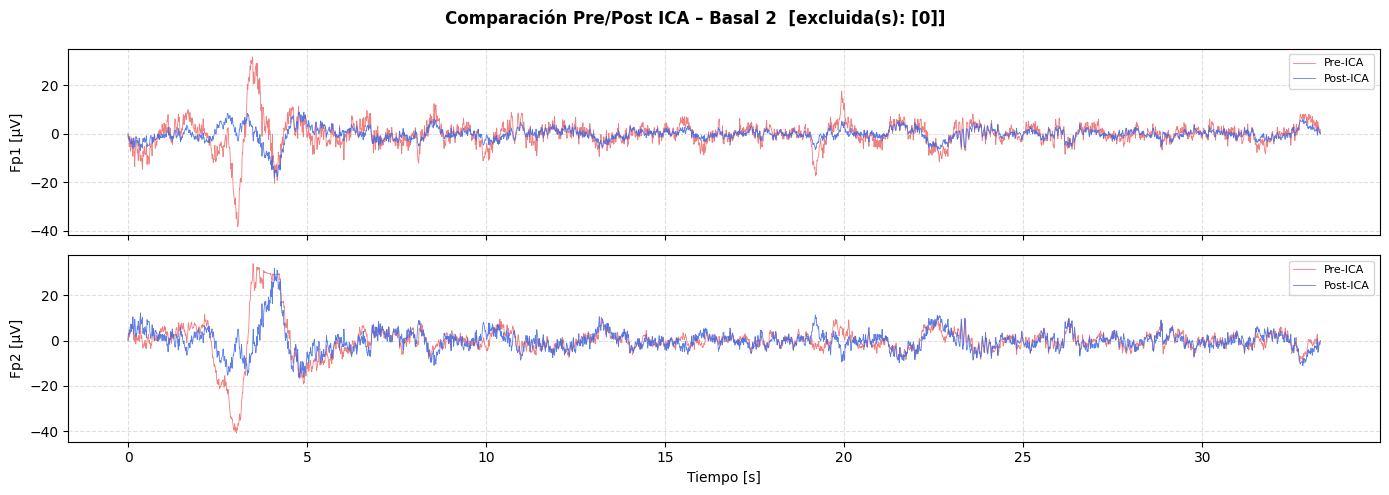

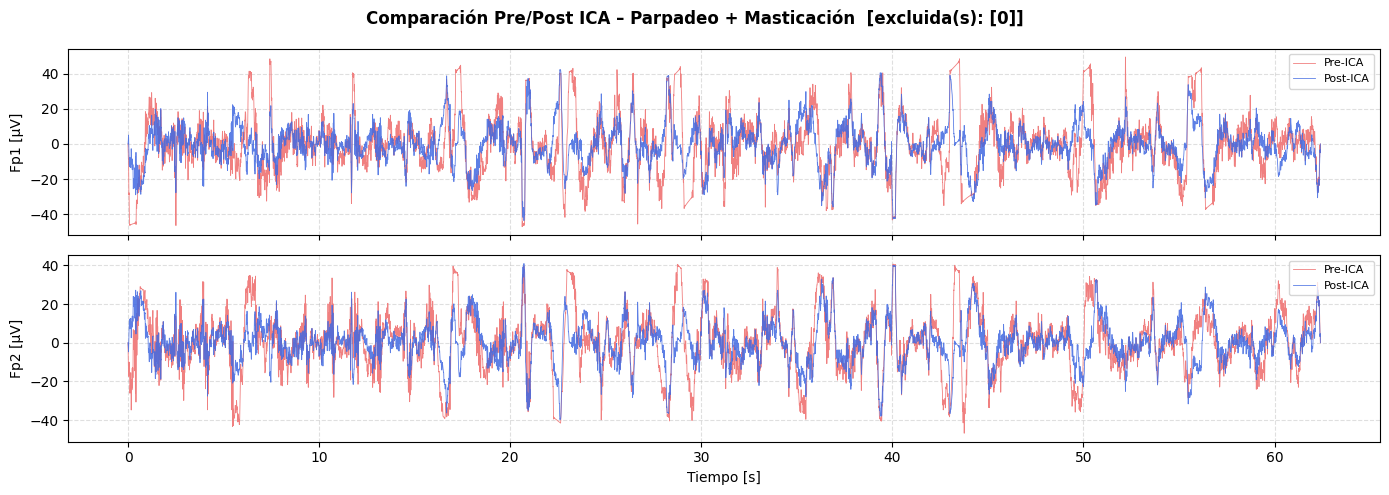

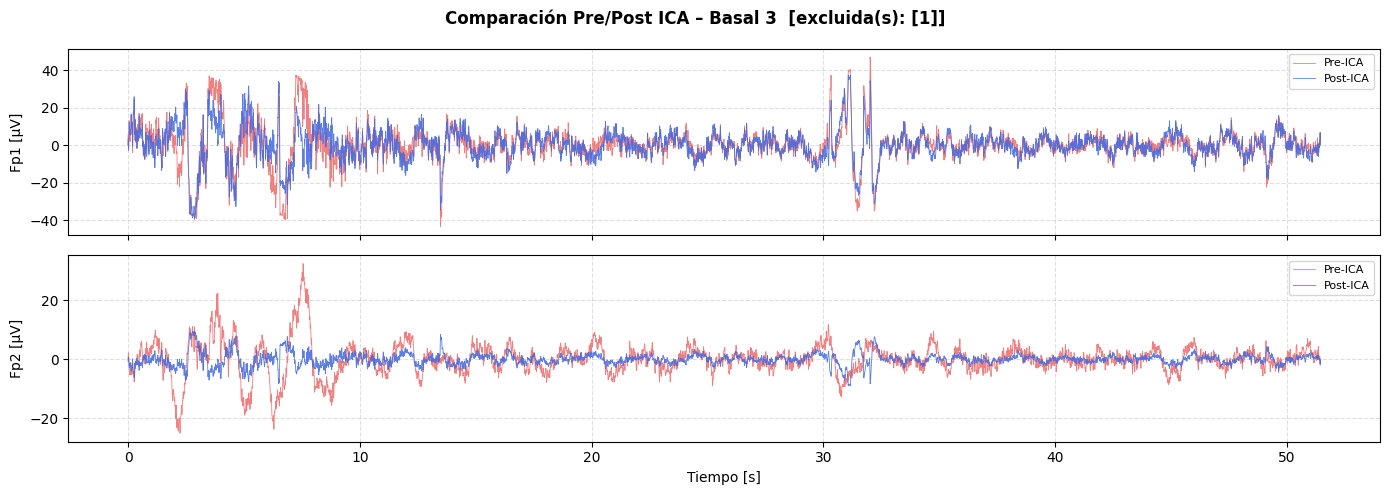

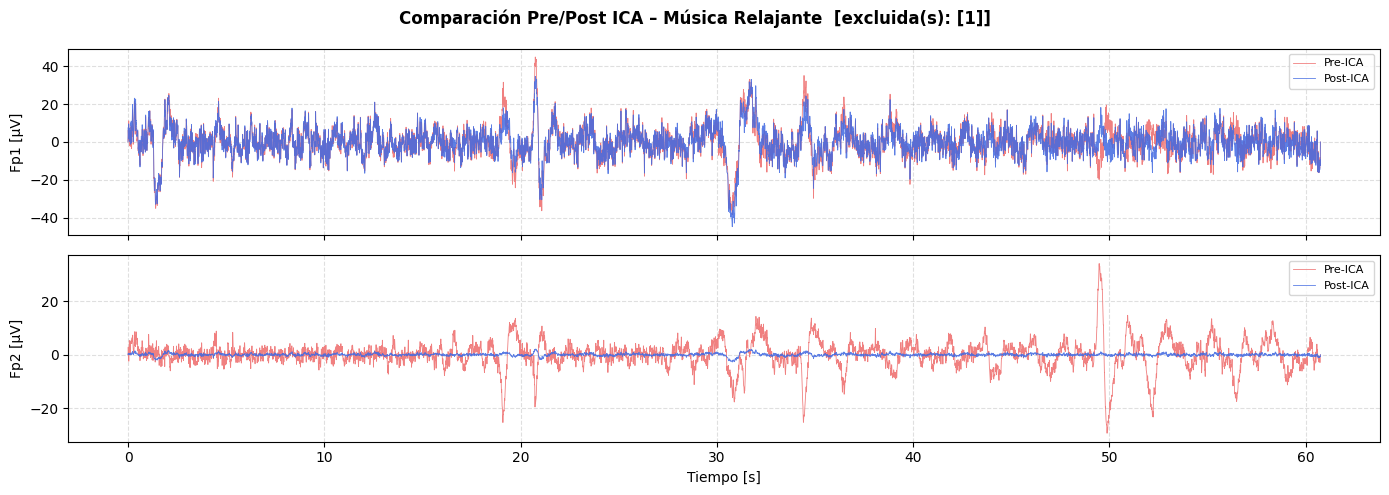

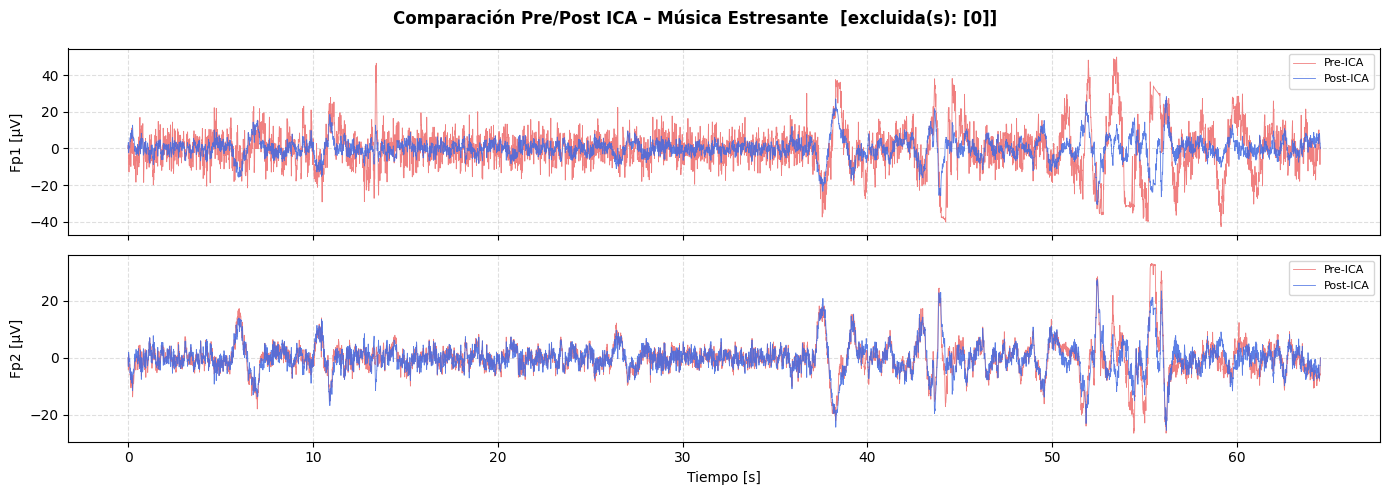

In [61]:
for nombre, d in datos.items():
    datos_suc = d["raw_filt"].get_data() * 1e6
    datos_lim = d["raw_limpio"].get_data() * 1e6
    t = np.arange(datos_suc.shape[1]) / FS

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    for i, ch in enumerate(CH_NAMES):
        axes[i].plot(t, datos_suc[i], lw=0.6, color="lightcoral", label="Pre-ICA")
        axes[i].plot(t, datos_lim[i], lw=0.6, color="royalblue", label="Post-ICA", alpha=0.85)
        axes[i].set_ylabel(f"{ch} [µV]")
        axes[i].legend(fontsize=8, loc="upper right")
        axes[i].grid(True, ls="--", alpha=0.4)
    axes[-1].set_xlabel("Tiempo [s]")
    fig.suptitle(f"Comparación Pre/Post ICA – {d['label']}  [excluida(s): {d['excluidas']}]",
                 fontweight="bold")
    plt.tight_layout(); plt.show()

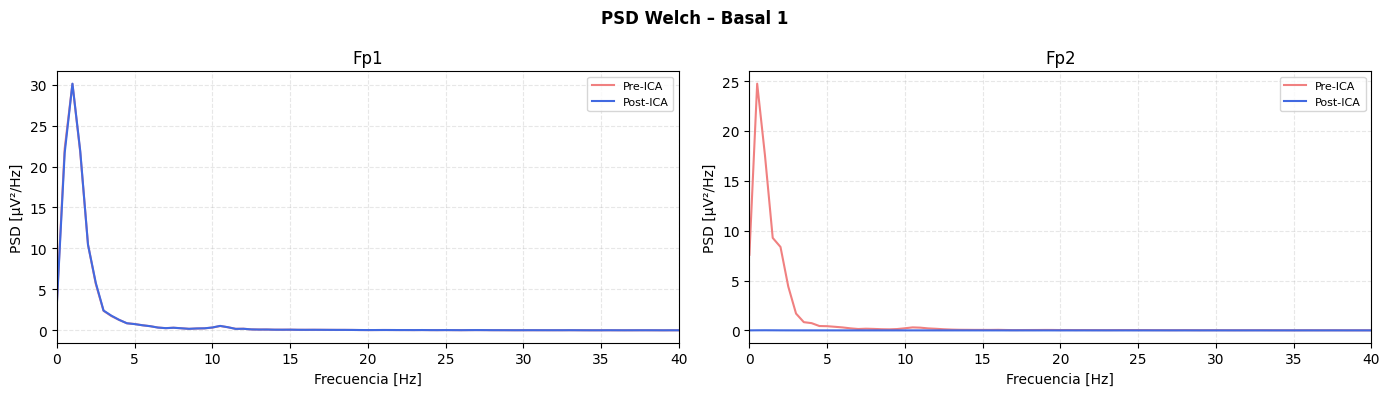

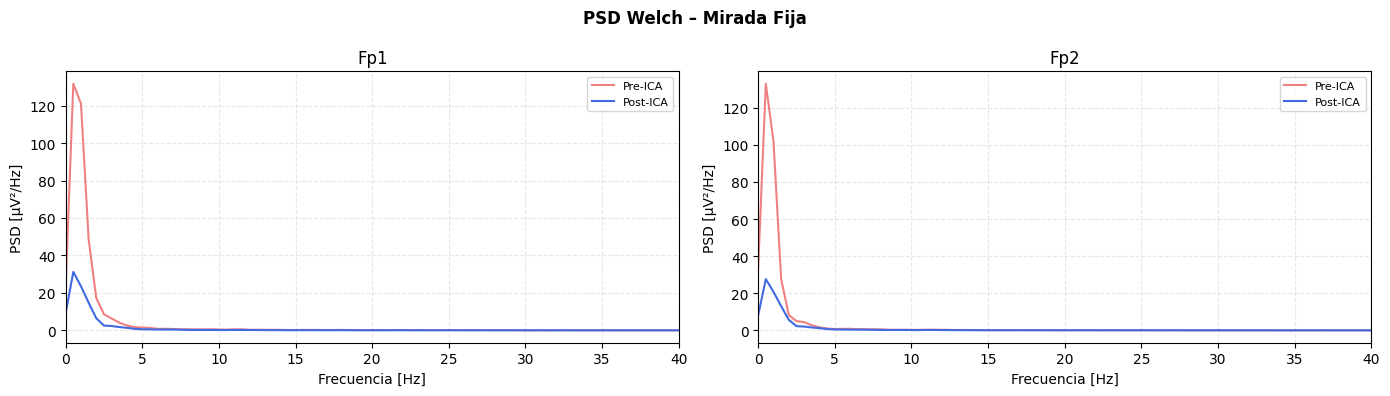

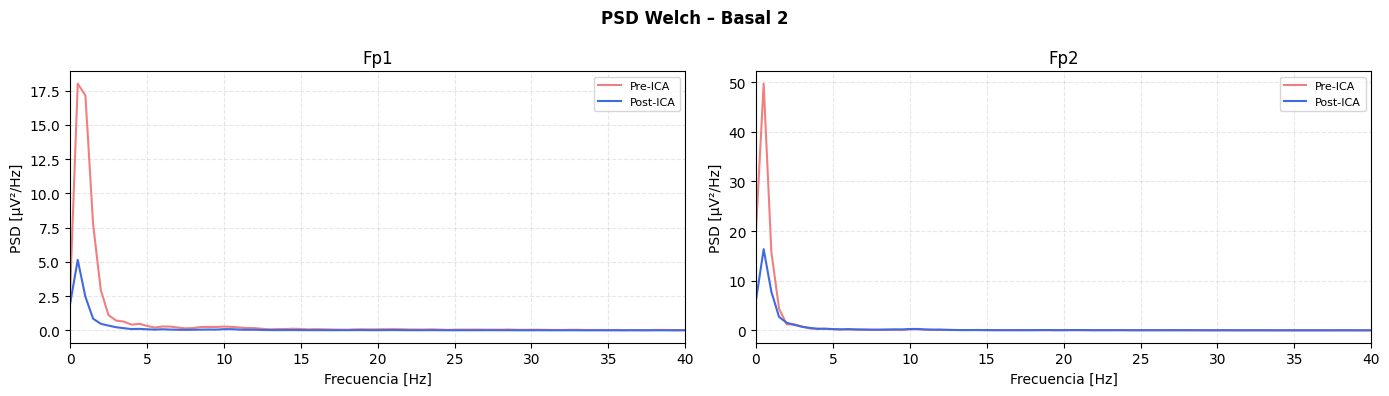

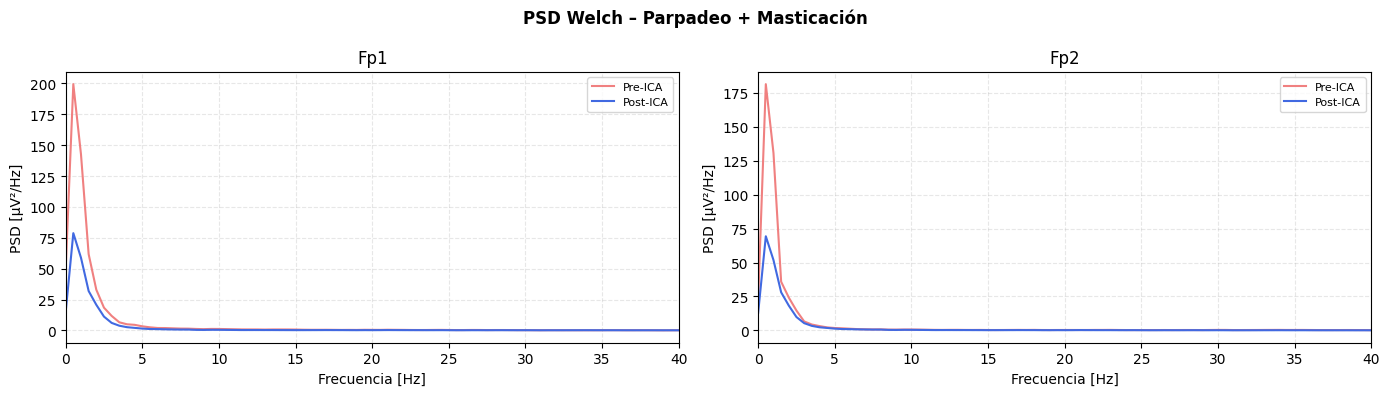

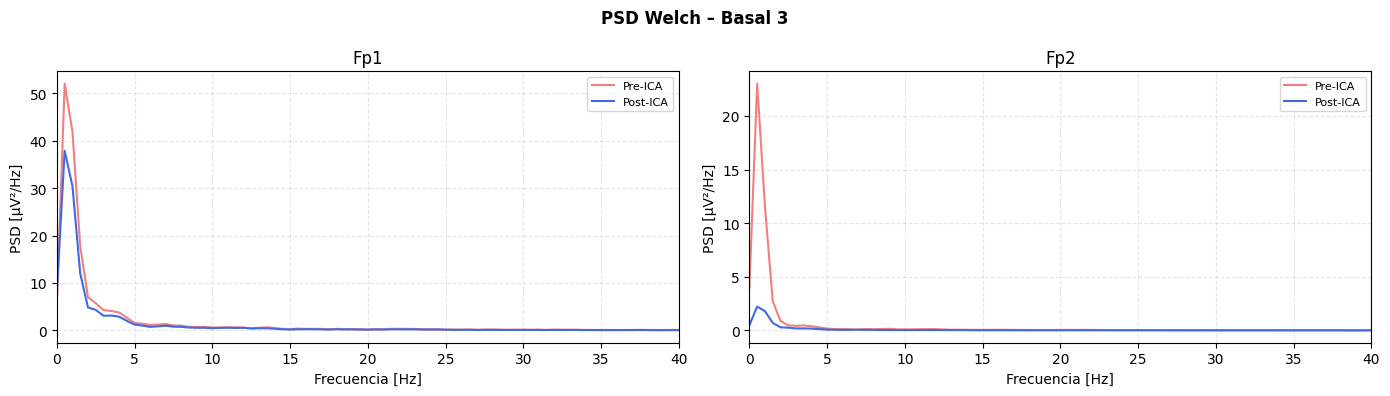

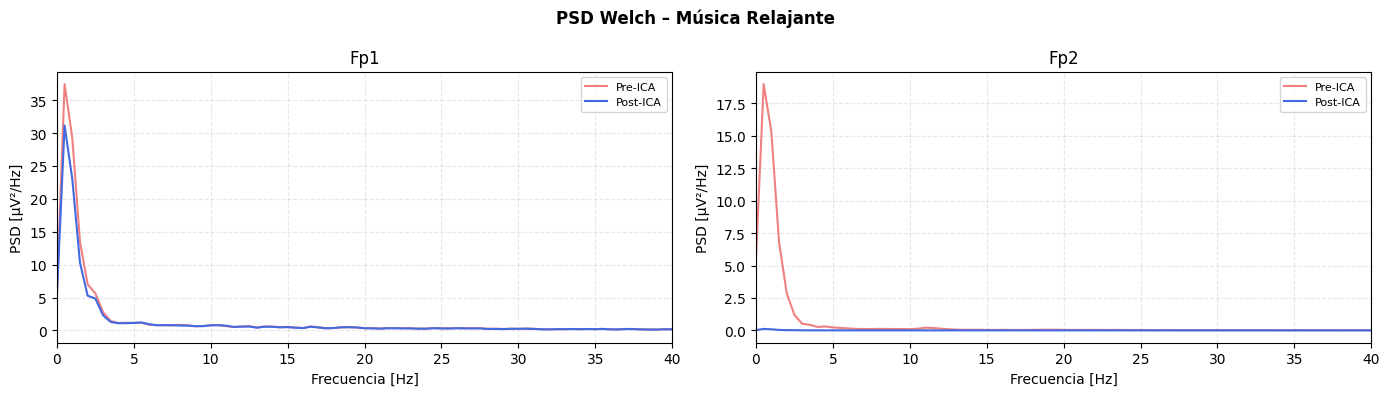

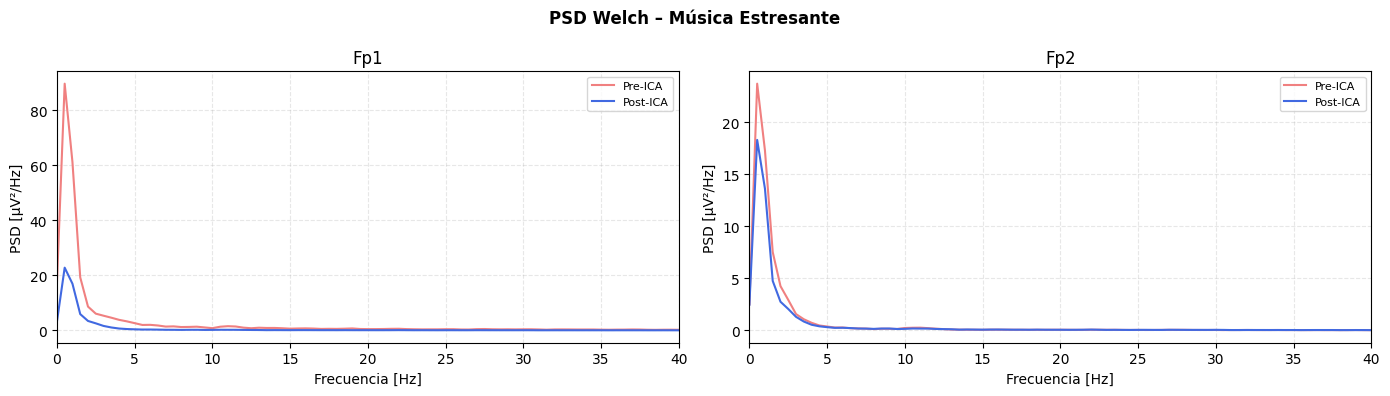

In [62]:
for nombre, d in datos.items():
    datos_suc = d["raw_filt"].get_data() * 1e6
    datos_lim = d["raw_limpio"].get_data() * 1e6

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, ch_i in zip(axes, range(2)):
        f_pre,  p_pre  = welch(datos_suc[ch_i], fs=FS, nperseg=2*FS)
        f_post, p_post = welch(datos_lim[ch_i], fs=FS, nperseg=2*FS)
        ax.plot(f_pre,  p_pre,  color="lightcoral", label="Pre-ICA")
        ax.plot(f_post, p_post, color="royalblue",  label="Post-ICA")
        ax.set_xlim(0, 40)
        ax.set_xlabel("Frecuencia [Hz]")
        ax.set_ylabel("PSD [µV²/Hz]")
        ax.set_title(CH_NAMES[ch_i])
        ax.legend(fontsize=8)
        ax.grid(True, ls="--", alpha=0.3)
    fig.suptitle(f"PSD Welch – {d['label']}", fontweight="bold")
    plt.tight_layout(); plt.show()

In [63]:
d = datos["4_Parpadeo_Y_Masticacion_Constante"]
datos_suc = d["raw_filt"].get_data() * 1e6
datos_lim = d["raw_limpio"].get_data() * 1e6

print("Amplitud pico a pico — Parpadeo + Masticación\n")
for i, ch in enumerate(CH_NAMES):
    p2p_suc = datos_suc[i].max() - datos_suc[i].min()
    p2p_lim = datos_lim[i].max() - datos_lim[i].min()
    reduccion = 100 * (p2p_suc - p2p_lim) / p2p_suc
    print(f"{ch}: pre-ICA = {p2p_suc:.2f} µV | post-ICA = {p2p_lim:.2f} µV | reducción = {reduccion:.1f}%")

# Cifra combinada (ambos canales), equivalente a lo que calculó el otro grupo
p2p_suc_total = datos_suc.max() - datos_suc.min()
p2p_lim_total = datos_lim.max() - datos_lim.min()
reduccion_total = 100 * (p2p_suc_total - p2p_lim_total) / p2p_suc_total
print(f"\nCombinado (Fp1+Fp2): pre-ICA = {p2p_suc_total:.2f} µV | post-ICA = {p2p_lim_total:.2f} µV | reducción = {reduccion_total:.1f}%")

Amplitud pico a pico — Parpadeo + Masticación

Fp1: pre-ICA = 96.68 µV | post-ICA = 85.98 µV | reducción = 11.1%
Fp2: pre-ICA = 87.64 µV | post-ICA = 80.67 µV | reducción = 7.9%

Combinado (Fp1+Fp2): pre-ICA = 96.68 µV | post-ICA = 85.98 µV | reducción = 11.1%
